In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xesmf as xe
import dask
from scipy.ndimage import label, binary_dilation
from scipy.ndimage import distance_transform_edt

In [2]:
PATH_NCEP_R1 = '/glade/campaign/cgd/oce/people/rita/NCEP_R1/'
PATH_NCEP_R2 = '/glade/campaign/cgd/oce/people/rita/NCEP_R2/'
PATH_CFSR = '/glade/campaign/cgd/oce/people/rita/CFSR/'
PATH_CFSv2 = '/glade/campaign/cgd/oce/people/rita/CFSv2/'
PATH_MERRA2 = '/glade/campaign/cgd/oce/people/rita/MERRA2/'
PATH_JRA3Q = '/glade/campaign/cgd/oce/people/rita/JRA-3Q/'
PATH_JRAdo = '/glade/campaign/cgd/oce/people/rita/JRA55do/'
PATH_20CRv3 = '/glade/campaign/cgd/oce/people/rita/20CRv3/'
PATH_ERA5 = '/glade/campaign/cgd/oce/people/rita/ERA5/'
PATH_ERAi = '/glade/campaign/cgd/oce/people/rita/ERA-Interim/'
PATH_ERA20C = '/glade/campaign/cgd/oce/people/rita/ERA20C/'


year_start = "1980"
year_fin = "2015"


filename_NCEP_R1 = 'air.2m.gauss.monthly_1948_2025.nc'
filename_NCEP_R2 = 'air.2m.gauss.monthly_1979_2025.nc'
filename_CFSR = 'tmp2m.monthly_1979_2010.nc'
filename_CFSv2 = 'tmp2m.monthly_2011_2020.nc' 
filename_MERRA2 = 'T2M_MERRA2.monthly_1980_2024.nc'
filename_JRA3Q = 'tmp2m.monthly.1947_2025.nc'
filename_JRAdo = 't_2.converted.reg_tl319.monthly_1958_2019.nc'
filename_20CRv3 = 'air.2m.monthly.1900_2015.nc'
filename_ERA5 = 'T2M.monthly_1940_2020.nc'
filename_ERAi = 'tmp2m_monthly_1979_2019.nc'
filename_ERA20C = '2t.monthly_1900_2010.nc'


varname_NCEP_R1 = 'air'
varname_NCEP_R2 = 'air'
varname_CFSR = '2t'
varname_CFSv2 = '2t'
varname_MERRA2 = 'T2M'
varname_JRA3Q = 'tmp2m-hgt-fc-gauss'
varname_JRAdo = 't_2'
varname_20CRv3 = 'air'
varname_ERA5 = 'T2M'
varname_ERAi = 'var167'
varname_ERA20C = 'var167'

In [3]:
mask_era5 = xr.open_dataset(PATH_ERA5 + '1940/194001_hres_cisst.nc', decode_times=False).isel(time=0)
ocean_mask = xr.where(mask_era5.SSTK.notnull(), 1, 0)
# ocean_mask.to_netcdf(PATH_ERA5 + "era5_landsea_mask.nc")

In [4]:
t2_ncep_r1 = xr.open_dataset(PATH_NCEP_R1 + filename_NCEP_R1)[varname_NCEP_R1].sel(time=slice(year_start, year_fin)).mean('time')
t2_ncep_r2 = xr.open_dataset(PATH_NCEP_R2 + filename_NCEP_R2)[varname_NCEP_R2].sel(time=slice(year_start, year_fin)).mean('time').isel(level =0)
t2_cfsr = xr.open_dataset(PATH_CFSR + filename_CFSR)[varname_CFSR].sel(time=slice(year_start, year_fin)).mean('time').isel(height = 0)
t2_cfsv2 = xr.open_dataset(PATH_CFSv2 + filename_CFSv2)[varname_CFSv2].sel(time=slice(year_start, year_fin)).mean('time').isel(height = 0)
t2_merra2 = xr.open_dataset(PATH_MERRA2 + filename_MERRA2)[varname_MERRA2].sel(time=slice(year_start, year_fin)).mean('time')
t2_jra3q = xr.open_dataset(PATH_JRA3Q + filename_JRA3Q)[varname_JRA3Q].sel(time=slice(year_start, year_fin)).mean('time')
t2_jrado = xr.open_dataset(PATH_JRAdo + filename_JRAdo)[varname_JRAdo].sel(time=slice(year_start, year_fin)).mean('time').rename({'latitude': 'lat', 'longitude':'lon'})
t2_20crv3 = xr.open_dataset(PATH_20CRv3 + filename_20CRv3)[varname_20CRv3].sel(time=slice(year_start, year_fin)).mean('time')
t2_era5 = xr.open_dataset(PATH_ERA5 + filename_ERA5)[varname_ERA5].sel(time=slice(year_start, year_fin)).mean('time')
t2_erai = xr.open_dataset(PATH_ERAi + filename_ERAi)[varname_ERAi].sel(time=slice(year_start, year_fin)).mean('time')
t2_era20c = xr.open_dataset(PATH_ERA20C + filename_ERA20C)[varname_ERA20C].sel(time=slice(year_start, year_fin)).mean('time')


t2_era5_1980_2010 = xr.open_dataset(PATH_ERA5 + filename_ERA5)[varname_ERA5].sel(time=slice(year_start, "2010")).mean('time')


# Reading masks 
for smooth transition around coastlines

In [5]:
mask_ncep_r1 = xr.open_dataset(PATH_NCEP_R1 + 'land.sfc.gauss.nc')['land'].isel(time=0, drop = True)
mask_ncep_r2 = xr.open_dataset(PATH_NCEP_R2 + 'land.sfc.gauss.nc')['land'].isel(time=0, drop = True)
mask_cfsr_raw = xr.open_dataset(PATH_CFSR + 'ocnsst.gdas.200001.nc')['pt'].isel(time=0, depth = 0, drop = True)
mask_cfsr = xr.where(mask_cfsr_raw.isnull(), 1, 0)
mask_cfsv2_raw = xr.open_dataset(PATH_CFSv2 + 'ocnsst.gdas.201101.nc')['pt'].isel(time=0, depth = 0, drop = True)
mask_cfsv2 = xr.where(mask_cfsv2_raw.isnull(), 1, 0)
mask_merra2_raw = xr.open_dataset(PATH_MERRA2 + 'MERRA2_masks.nc')['FROCEAN'].isel(time=0, drop = True)
mask_merra2 = xr.where(mask_merra2_raw < 0.9, 1, 0)
mask_jra3q_raw = xr.open_dataset(PATH_JRA3Q + 'jra3q.bnd_ocean.10_3_0.wtmp-sfc-fc-gauss.1947090100_1947093023.nc')['wtmp-sfc-fc-gauss'].isel(time=0, drop = True)
mask_jra3q = xr.where(mask_jra3q_raw.isnull(), 1, 0)
mask_jrado_raw = xr.open_dataset('/glade/campaign/cgd/oce/people/rita/JRA55raw/landsea_mask/tl319.081_land.reg_tl319.1958.nc')['var81'].isel(time=0, drop = True)
mask_jrado = xr.where(mask_jrado_raw < 0.9, 0, 1)
mask_20crv3 = xr.open_dataset(PATH_20CRv3 + 'landsea_mask_20CRv3.nc')['land'].isel(time=0, drop = True)
mask_era5 = 1 - xr.open_dataset(PATH_ERA5 + 'era5_landsea_mask.nc')['SSTK']
mask_erai_raw = xr.open_dataset(PATH_ERAi + 'sst_1979.nc')['var34'].isel(time=0, drop = True)
mask_erai = xr.where(mask_erai_raw.isnull(), 1, 0)

/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/xarray/conventions.py:193: SerializationWarning: variable 'land' has multiple fill values {-32767, 32766} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [6]:
# reorder MERRA so its lons go from -180:180 - otherwise it doesn't regrid to ERA5 grid correctly 
merra2_shifted = t2_merra2.copy()
merra2_shifted['lon'] = (merra2_shifted.lon + 360) % 360
merra2_shifted = merra2_shifted.sortby('lon')

merra2_mask_shifted = mask_merra2.copy()
merra2_mask_shifted['lon'] = (merra2_mask_shifted.lon + 360) % 360
merra2_mask_shifted = merra2_mask_shifted.sortby('lon')

# Interpolate all reanalyses to ERA5 grid

In [7]:
t2_ncep_r1_interp = t2_ncep_r1.interp(lat=t2_era5.lat, lon=t2_era5.lon)
t2_ncep_r2_interp = t2_ncep_r2.interp(lat=t2_era5.lat, lon=t2_era5.lon)
t2_cfsr_interp = t2_cfsr.interp(lat=t2_era5.lat, lon=t2_era5.lon)
t2_cfsv2_interp = t2_cfsv2.interp(lat=t2_era5.lat, lon=t2_era5.lon)
t2_merra2_interp = merra2_shifted.interp(lat=t2_era5.lat, lon=t2_era5.lon)
t2_jra3q_interp = t2_jra3q.interp(lat=t2_era5.lat, lon=t2_era5.lon)
t2_jrado_interp = t2_jrado.interp(lat=t2_era5.lat, lon=t2_era5.lon)
t2_20crv3_interp = t2_20crv3.interp(lat=t2_era5.lat, lon=t2_era5.lon)
t2_erai_interp = t2_erai.interp(lat=t2_era5.lat, lon=t2_era5.lon)
# t2_era20c_interp = t2_era20c.interp(lat=t2_era5.lat, lon=t2_era5.lon)

t2_cfsr_interp = xr.concat([t2_cfsr_interp, t2_cfsv2_interp], dim="rean").mean(dim="rean", skipna=True)

In [ ]:
# Create weigths with transition from open ocean (1) to land (0)

Text(0.5, 1.0, 'Ocean Weights Based on Distance from Coast (0–1)')

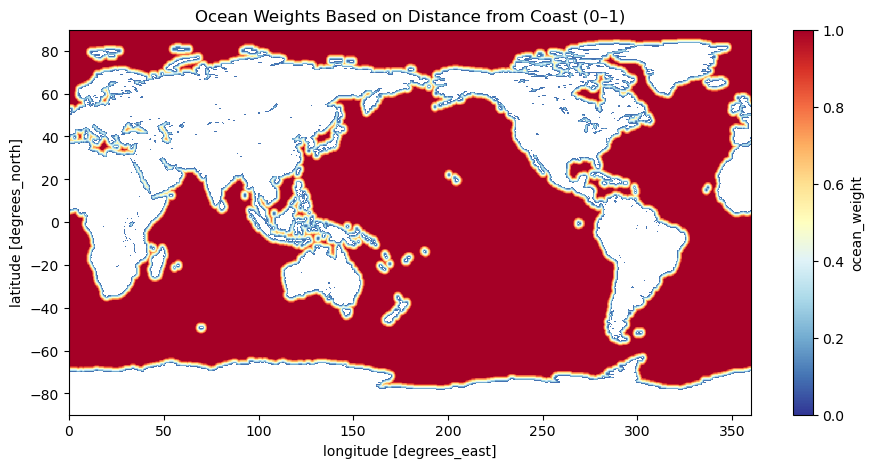

In [8]:
# Step 1: Get the ocean mask as numpy array (1 = ocean, 0 = land)
ocean_np = ocean_mask.values.astype(int)

# Step 2: Compute distance from land (land = 0, so we invert ocean to get land)
land_mask = ocean_np  # 1 = land, 0 = ocean
distance_from_land = distance_transform_edt(land_mask)

# Step 3: Create weight field — linear increase from 0 to 1 over 5 grid points
weights = np.clip(distance_from_land / 10.0, 0, 1)

# Step 4: Ensure land is zero-weight (mask it out)
weights = weights * ocean_np

# Step 5: Wrap as xarray
weights_da = xr.DataArray(
    weights,
    coords=ocean_mask.coords,
    dims=ocean_mask.dims,
    name='ocean_weight'
)

# Step 6: Plot it
plt.figure(figsize=(11, 5))
weights_da.where(ocean_mask == 1).plot(cmap='RdYlBu_r', vmin=0, vmax=1)
plt.title("Ocean Weights Based on Distance from Coast (0–1)")


Text(0.5, 1.0, 'Ocean Weights: Enclosed Basins = 0, Linear Transition from Coast')

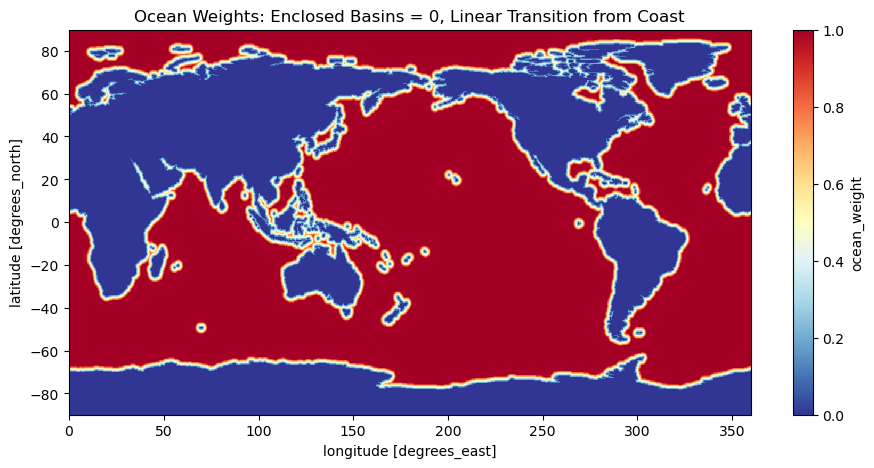

In [9]:
# Step 1: Get the ocean mask as numpy array (1 = ocean, 0 = land)
ocean_np = ocean_mask.values.astype(int)

# Step 1.5: Identify and keep only the largest connected ocean
labeled_ocean, num_features = label(ocean_np)
counts = np.bincount(labeled_ocean.ravel())
largest_ocean_label = counts[1:].argmax() + 1  # skip label=0 (background)
ocean_main = (labeled_ocean == largest_ocean_label).astype(int)  # 1 = main ocean, 0 = enclosed seas

# Step 2: Compute distance from land (land = 1, ocean = 0)
land_mask = ocean_main  # main ocean = 1, everything else = land or masked

# Step 3: Create weight field — linear ramp (e.g. 10 grid points wide)
distance_from_land = distance_transform_edt(land_mask)
weights = np.clip(distance_from_land / 10.0, 0, 1)

# Step 4: Mask everything not in main ocean (enclosed seas = 0)
weights = weights * ocean_main

# Step 5: Wrap as xarray
weights_da = xr.DataArray(
    weights,
    coords=ocean_mask.coords,
    dims=ocean_mask.dims,
    name='ocean_weight'
)

# Step 6: Plot it
plt.figure(figsize=(11, 5))
weights_da.plot(cmap='RdYlBu_r', vmin=0, vmax=1)
plt.title("Ocean Weights: Enclosed Basins = 0, Linear Transition from Coast")


In [10]:
t2_ens_mean = xr.concat([
    t2_ncep_r1_interp, t2_ncep_r2_interp, t2_cfsr_interp,
    t2_merra2_interp,  t2_jra3q_interp, t2_20crv3_interp, t2_erai_interp], dim="model").mean(dim="model", skipna=True)

Text(0.5, 1.0, 'ERA5 - Ens mean (0 at the coast, 1 in open ocean >2.5°)')

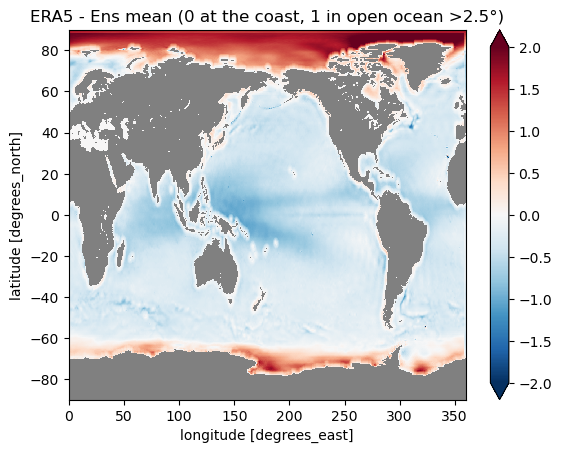

In [11]:
t2_blended = (1 - weights_da) * t2_era5 + weights_da * t2_ens_mean

t2_diff_weighted = t2_era5 - t2_blended

cmap = plt.get_cmap('RdBu_r').copy()
cmap.set_bad(color='gray')  # or '0.8' for darker grey

# Plot with masked land (NaN) as gray
t2_diff_weighted.where(ocean_mask == 1).plot(cmap=cmap, vmin=-2, vmax=2)
plt.title("ERA5 - Ens mean (0 at the coast, 1 in open ocean >2.5°)")

In [12]:
# %%time 
# print('NCEP R1')
# t2_ncep_r1_ocean_only = t2_ncep_r1_interp.where(ocean_mask_expanded == 0)
# t2_ncep_r1_extrap = t2_ncep_r1_ocean_only.sortby('lat').interpolate_na(
#     dim="lon", method="nearest", fill_value="extrapolate"
# ).interpolate_na(
#     dim="lat", method="nearest", fill_value="extrapolate"
# )


# print('NCEP R2')
# t2_ncep_r2_ocean_only = t2_ncep_r2.where(mask_ncep_r2 == 0)
# t2_ncep_r2_interp = t2_ncep_r2_ocean_only.interp(lat=t2_era5.lat, lon=t2_era5.lon)
# t2_ncep_r2_interp_filled = t2_ncep_r2_interp.sortby('lat').interpolate_na(
#     dim="lon", method="nearest", fill_value="extrapolate"
# ).interpolate_na(
#     dim="lat", method="nearest", fill_value="extrapolate"
# )

# print('JRA-do')
# t2_jrado_ocean_only = t2_jrado.where(mask_jrado == 0)
# t2_jrado_interp = t2_jrado_ocean_only.interp(lat=t2_era5.lat, lon=t2_era5.lon)
# t2_jrado_interp_filled = t2_jrado_interp.sortby('lat').interpolate_na(
#     dim="lon", method="nearest", fill_value="extrapolate"
# ).interpolate_na(
#     dim="lat", method="nearest", fill_value="extrapolate"
# )

# print('MERRA2')
# t2_merra2_ocean_only = t2_merra2.where(mask_merra2 == 0)
# t2_merra2_interp = t2_merra2_ocean_only.interp(lat=t2_era5.lat, lon=t2_era5.lon)
# t2_merra2_interp_filled = t2_merra2_interp.sortby('lat').interpolate_na(
#     dim="lon", method="nearest", fill_value="extrapolate"
# ).interpolate_na(
#     dim="lat", method="nearest", fill_value="extrapolate"
# )

# print('JRA3Q')
# t2_jra3q_ocean_only = t2_jra3q.where(mask_jra3q == 0)
# t2_jra3q_interp = t2_jra3q_ocean_only.interp(lat=t2_era5.lat, lon=t2_era5.lon)
# t2_jra3q_interp_filled = t2_jra3q_interp.sortby('lat').interpolate_na(
#     dim="lon", method="nearest", fill_value="extrapolate"
# ).interpolate_na(
#     dim="lat", method="nearest", fill_value="extrapolate"
# )


# print('20C')
# t2_20crv3_ocean_only = t2_20crv3.where(mask_20crv3 == 0)
# t2_20crv3_interp = t2_20crv3_ocean_only.interp(lat=t2_era5.lat, lon=t2_era5.lon)
# t2_20crv3_interp_filled = t2_20crv3_interp.sortby('lat').interpolate_na(
#     dim="lon", method="nearest", fill_value="extrapolate"
# ).interpolate_na(
#     dim="lat", method="nearest", fill_value="extrapolate"
# )

# print('ERAi')
# t2_erai_ocean_only = t2_erai.where(mask_erai == 0)
# t2_erai_interp = t2_erai_ocean_only.interp(lat=t2_era5.lat, lon=t2_era5.lon)
# t2_erai_interp_filled = t2_erai_interp.sortby('lat').interpolate_na(
#     dim="lon", method="nearest", fill_value="extrapolate"
# ).interpolate_na(
#     dim="lat", method="nearest", fill_value="extrapolate"
# )

# # t2_cfsr_interp_filled = xr.concat([t2_cfsr_interp_filled, t2_cfsv2_interp_filled], dim="rean").mean(dim="rean", skipna=True)

# # t2_cfsr_ocean_only = t2_cfsr.isel(height = 0).where(mask_cfsr == 0)
# # t2_cfsr_interp = t2_cfsr_ocean_only.interp(lat=t2_era5.lat, lon=t2_era5.lon)
# # t2_cfsr_interp_filled = t2_cfsr_interp.sortby('lat').interpolate_na(
# #     dim="lon", method="nearest", fill_value="extrapolate"
# # ).interpolate_na(
# #     dim="lat", method="nearest", fill_value="extrapolate"
# # )


# # t2_cfsv2_ocean_only = t2_cfsv2.where(mask_cfsv2 == 0)
# # t2_cfsv2_interp = t2_cfsv2_ocean_only.interp(lat=t2_era5.lat, lon=t2_era5.lon)
# # t2_cfsv2_interp_filled = t2_cfsv2_interp.sortby('lat').interpolate_na(
# #     dim="lon", method="nearest", fill_value="extrapolate"
# # ).interpolate_na(
# #     dim="lat", method="nearest", fill_value="extrapolate"
# # )

# Plot regional differences

Text(0.5, 1.0, 'T2: ERA5 - NCEP R1: 1980-2015')

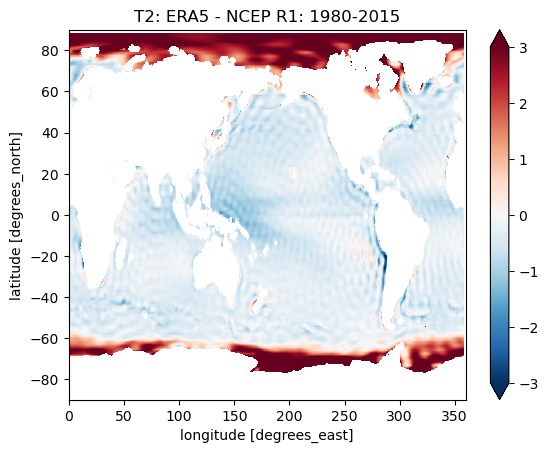

In [21]:
(t2_era5 - t2_ncep_r1_interp).where(ocean_mask_expanded == 1).plot(vmin = -3, vmax = 3, cmap = 'RdBu_r')
plt.title('T2: ERA5 - NCEP R1: ' + year_start + '-' + year_fin)

Text(0.5, 1.0, 'T2: ERA5 - JRA55do: 1980-2015')

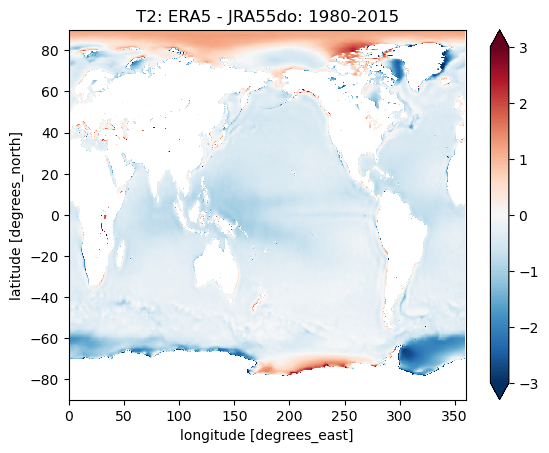

In [19]:
(t2_era5 - t2_jrado_interp).where(ocean_mask == 1).plot(vmin = -3, vmax = 3, cmap = 'RdBu_r')
plt.title('T2: ERA5 - JRA55do: ' + year_start + '-' + year_fin)

# Zonal mean biases

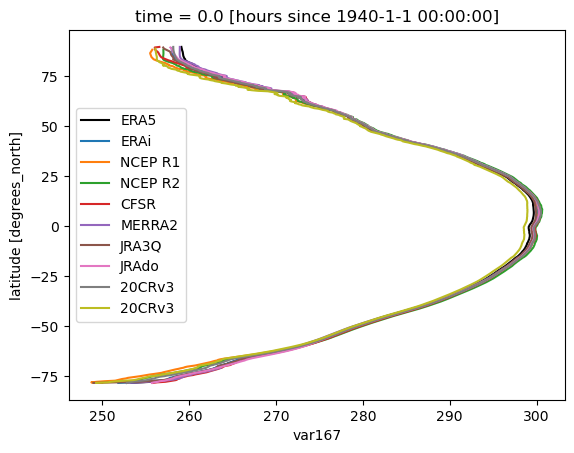

In [53]:
t2_era5.where(ocean_mask == 1).mean('lon').plot(y = 'lat', label = 'ERA5', c = 'k')
t2_erai_interp.where(ocean_mask == 1).mean('lon').plot(y = 'lat', label = 'ERAi') 
t2_ncep_r1_interp.where(ocean_mask == 1).mean('lon').plot(y = 'lat', label = 'NCEP R1') 
t2_ncep_r2_interp.where(ocean_mask == 1).mean('lon').plot(y = 'lat', label = 'NCEP R2') 
t2_cfsr_interp.where(ocean_mask == 1).mean('lon').plot(y = 'lat', label = 'CFSR')
t2_merra2_interp.where(ocean_mask == 1).mean('lon').plot(y = 'lat', label = 'MERRA2')
t2_jra3q_interp.where(ocean_mask == 1).mean('lon').plot(y = 'lat', label = 'JRA3Q')
t2_jrado_interp.where(ocean_mask == 1).mean('lon').plot(y = 'lat', label = 'JRAdo')
t2_20crv3_interp.where(ocean_mask == 1).mean('lon').plot(y = 'lat', label = '20CRv3')
t2_era20c_interp.where(ocean_mask == 1).mean('lon').plot(y = 'lat', label = '20CRv3')

plt.legend()

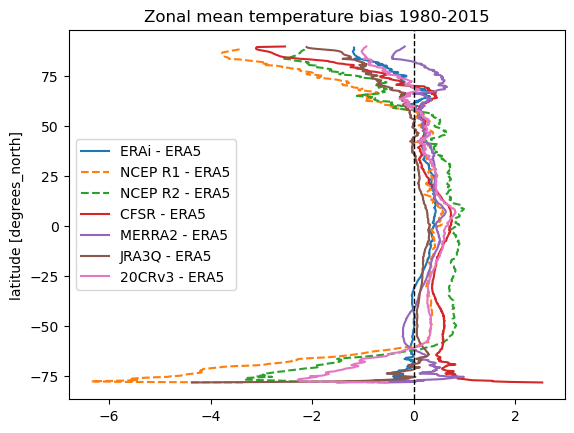

In [73]:
(t2_erai_interp.where(ocean_mask == 1).mean('lon') - t2_era5.where(ocean_mask == 1).mean('lon')).plot(y = 'lat', label = 'ERAi - ERA5') 
(t2_ncep_r1_interp.where(ocean_mask == 1).mean('lon') - t2_era5.where(ocean_mask == 1).mean('lon')).plot(y = 'lat', label = 'NCEP R1 - ERA5', linestyle='--') 
(t2_ncep_r2_interp.where(ocean_mask == 1).mean('lon') - t2_era5.where(ocean_mask == 1).mean('lon')).plot(y = 'lat', label = 'NCEP R2 - ERA5', linestyle='--') 
(t2_cfsr_interp.where(ocean_mask == 1).mean('lon') - t2_era5.where(ocean_mask == 1).mean('lon')).plot(y = 'lat', label = 'CFSR - ERA5')
(t2_merra2_interp.where(ocean_mask == 1).mean('lon') - t2_era5.where(ocean_mask == 1).mean('lon')).plot(y = 'lat', label = 'MERRA2 - ERA5')
(t2_jra3q_interp.where(ocean_mask == 1).mean('lon') - t2_era5.where(ocean_mask == 1).mean('lon')).plot(y = 'lat', label = 'JRA3Q - ERA5')
# (t2_jrado_interp.where(ocean_mask == 1).mean('lon') - t2_era5.where(ocean_mask == 1).mean('lon')).plot(y = 'lat', label = 'JRAdo - ERA5', c = 'gray', linestyle='--')
(t2_20crv3_interp.where(ocean_mask == 1).mean('lon') - t2_era5.where(ocean_mask == 1).mean('lon')).plot(y = 'lat', label = '20CRv3 - ERA5')
# (t2_era20c_interp.where(ocean_mask == 1).mean('lon') - t2_era5.where(ocean_mask == 1).mean('lon')).plot(y = 'lat', label = 'ERA20C - ERA5', linestyle='--')
plt.axvline(x=0, color='k', linestyle='--', linewidth=1)
plt.title('Zonal mean temperature bias ' + year_start + '-' + year_fin)
plt.legend()

# Spatial patterns of biases

Text(0.5, 1.0, 'T2: ERA5 - JRA55do: 1980-2015')

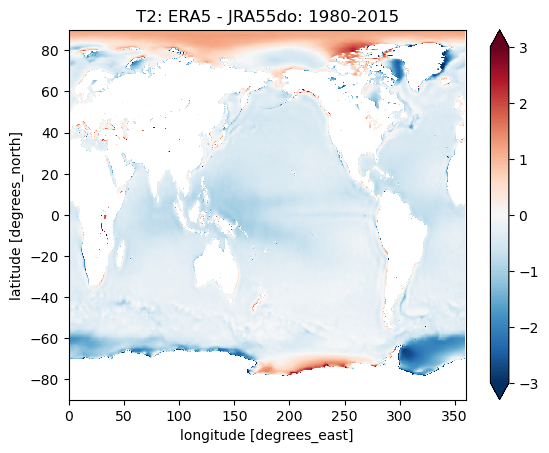

Text(0.5, 1.0, 'T2: ERA5 - ERA20C: 1980-2015')

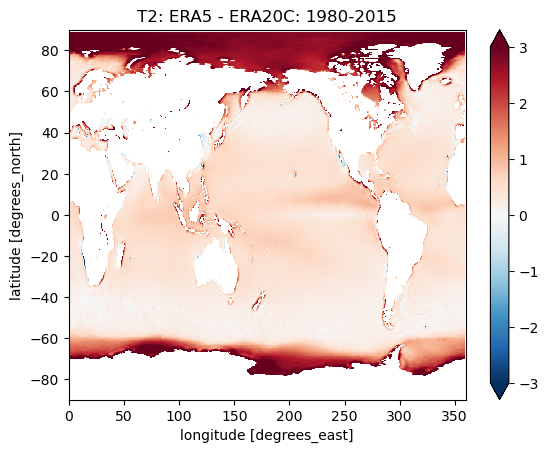

In [56]:
(t2_era5_1980_2010 - t2_era20c_interp).where(ocean_mask == 1).plot(vmin = -3, vmax = 3, cmap = 'RdBu_r')
plt.title('T2: ERA5 - ERA20C: ' + year_start + '-' + year_fin)

Text(0.5, 1.0, 'T2: ERA5 - ERAi: 1980-2015')

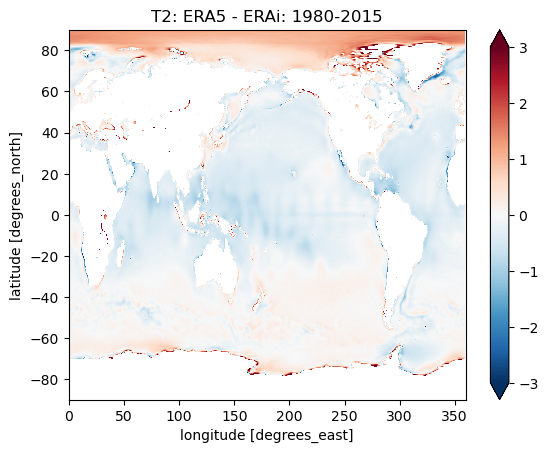

In [57]:
(t2_era5 - t2_erai_interp).where(ocean_mask == 1).plot(vmin = -3, vmax = 3, cmap = 'RdBu_r')
plt.title('T2: ERA5 - ERAi: ' + year_start + '-' + year_fin)

Text(0.5, 1.0, 'T2: ERA5 - MERRA2: 1980-2015')

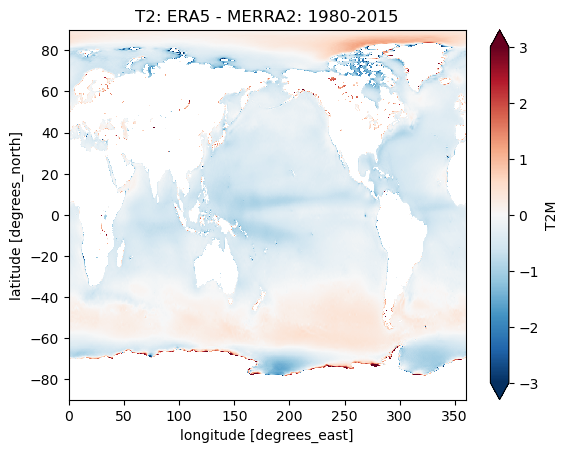

In [58]:
(t2_era5 - t2_merra2_interp).where(ocean_mask == 1).plot(vmin = -3, vmax = 3, cmap = 'RdBu_r')
plt.title('T2: ERA5 - MERRA2: ' + year_start + '-' + year_fin)

Text(0.5, 1.0, 'T2: ERA5 - CFSR: 1980-2015')

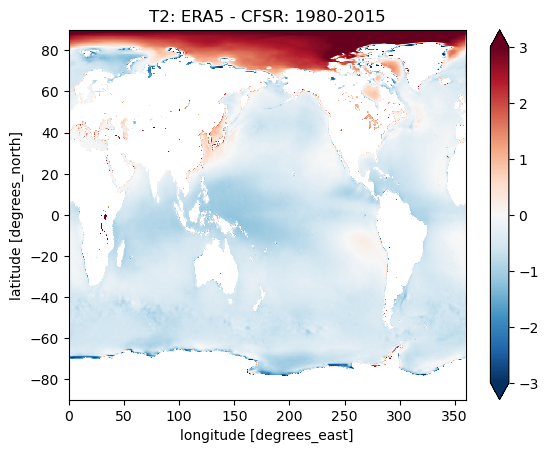

In [59]:
(t2_era5 - t2_cfsr_interp).where(ocean_mask == 1).plot(vmin = -3, vmax = 3, cmap = 'RdBu_r')
plt.title('T2: ERA5 - CFSR: ' + year_start + '-' + year_fin)

Text(0.5, 1.0, 'T2: ERA5 - NCEP R1: 1980-2015')

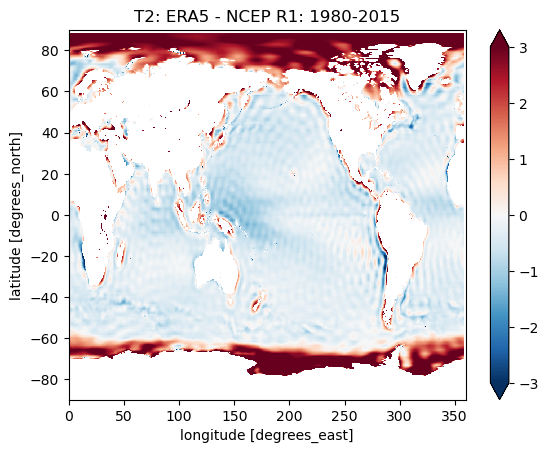

In [60]:
(t2_era5 - t2_ncep_r1_interp).where(ocean_mask == 1).plot(vmin = -3, vmax = 3, cmap = 'RdBu_r')
plt.title('T2: ERA5 - NCEP R1: ' + year_start + '-' + year_fin)

Text(0.5, 1.0, 'T2: ERA5 - NCEP R2: 1980-2015')

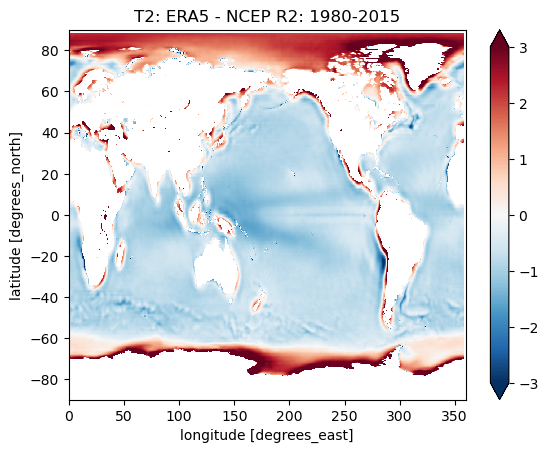

In [61]:
(t2_era5 - t2_ncep_r2_interp).where(ocean_mask == 1).plot(vmin = -3, vmax = 3, cmap = 'RdBu_r')
plt.title('T2: ERA5 - NCEP R2: ' + year_start + '-' + year_fin)

Text(0.5, 1.0, 'T2: ERA5 - JRA3Q: 1980-2015')

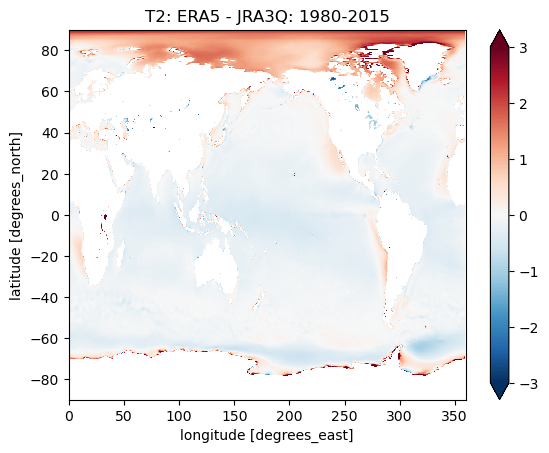

In [62]:
(t2_era5 - t2_jra3q_interp).where(ocean_mask == 1).plot(vmin = -3, vmax = 3, cmap = 'RdBu_r')
plt.title('T2: ERA5 - JRA3Q: ' + year_start + '-' + year_fin)

Text(0.5, 1.0, 'T2: ERA5 - 20CRv3: 1980-2015')

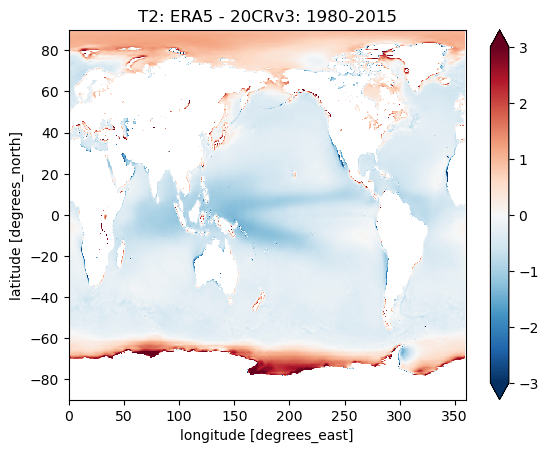

In [63]:
(t2_era5 - t2_20crv3_interp).where(ocean_mask == 1).plot(vmin = -3, vmax = 3, cmap = 'RdBu_r')
plt.title('T2: ERA5 - 20CRv3: ' + year_start + '-' + year_fin)

In [64]:
ens_mean = xr.concat([
    t2_ncep_r1_interp, t2_ncep_r2_interp, t2_cfsr_interp,
    t2_merra2_interp,  t2_jra3q_interp, t2_20crv3_interp, t2_erai_interp], dim="model").mean(dim="model", skipna=True)

Text(0.5, 1.0, 'T2: ERA5 - Ens mean (no weighting)1980-2015\n(NCEP R1/R2, CFSR, MERRA2, JRA-3Q, 20CRv3, ERAi)')

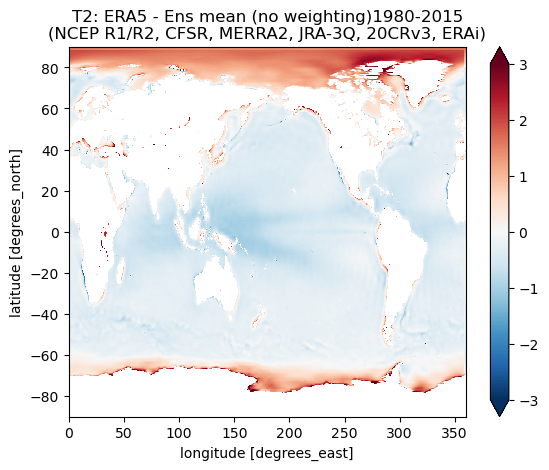

In [65]:
(t2_era5 - ens_mean).where(ocean_mask == 1).plot(vmin = -3, vmax = 3, cmap = 'RdBu_r')
plt.title('T2: ERA5 - Ens mean (no weighting)' + year_start + '-' + year_fin + '\n(NCEP R1/R2, CFSR, MERRA2, JRA-3Q, 20CRv3, ERAi)')

In [66]:
# datasets = np.stack([t2_ncep_r1_interp, t2_ncep_r2_interp.isel(level = 0), t2_era20c_interp, t2_20crv3_interp, 
#                      t2_cfsr_interp.isel(height = 0), t2_merra2_interp,  t2_jra3q_interp,  t2_erai_interp])

datasets = np.stack([t2_ncep_r1_interp, t2_ncep_r2_interp.isel(level = 0), t2_20crv3_interp, 
                     t2_cfsr_interp.isel(height = 0), t2_merra2_interp,  t2_jra3q_interp,  t2_erai_interp])

weights = np.array([0.5, 0.5, 1.0, 1.0, 1.0, 1.0, 1.0])[:, None, None]

ens_mean_weighted_np = np.sum(weights * datasets, axis=0) / np.sum(weights)

ens_mean_weighted = xr.DataArray(
    ens_mean_weighted_np,
    dims=["lat", "lon"],
    coords={
        "lat": t2_era5.lat,
        "lon": t2_era5.lon
    },
    name="t2_ensemble_mean"
)

Text(0.5, 1.0, 'T2: ERA5 - Ens mean (weighted) 1980-2015\n(NCEP R1/R2, CFSR, MERRA2, JRA-3Q, 20CRv3, ERAi)')

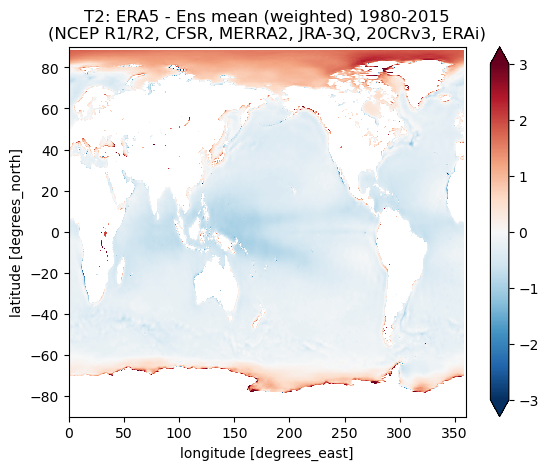

In [70]:
(t2_era5 - ens_mean_weighted).where(ocean_mask == 1).plot(vmin = -3, vmax = 3, cmap = 'RdBu_r')
plt.title('T2: ERA5 - Ens mean (weighted) ' + year_start + '-' + year_fin + '\n(NCEP R1/R2, CFSR, MERRA2, JRA-3Q, 20CRv3, ERAi)')

Text(0.5, 1.0, 'T2: JRAdo - Ens mean (weighted) 1980-2015\n(NCEP R1/R2, CFSR, MERRA2, JRA-3Q, 20CRv3, ERAi)')

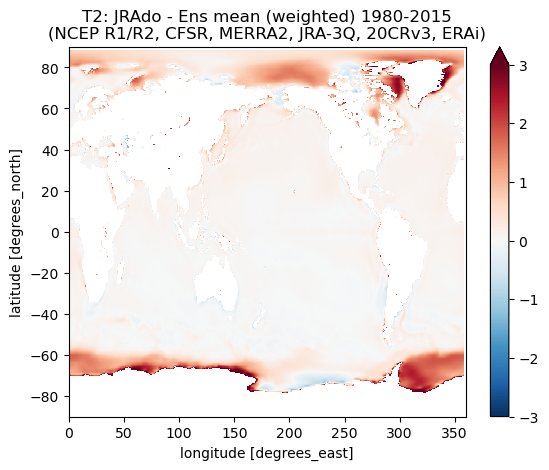

In [68]:
(t2_jrado_interp - ens_mean_weighted).where(ocean_mask == 1).plot(vmin = -3, vmax = 3, cmap = 'RdBu_r')
plt.title('T2: JRAdo - Ens mean (weighted) ' + year_start + '-' + year_fin + '\n(NCEP R1/R2, CFSR, MERRA2, JRA-3Q, 20CRv3, ERAi)')

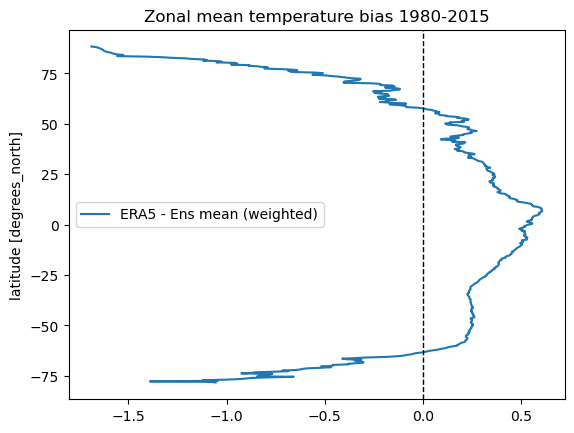

In [72]:
(ens_mean_weighted.where(ocean_mask == 1).mean('lon') - t2_era5.where(ocean_mask == 1).mean('lon')).plot(y = 'lat', label = 'ERA5 - Ens mean (weighted)') 
plt.axvline(x=0, color='k', linestyle='--', linewidth=1)
plt.title('Zonal mean temperature bias ' + year_start + '-' + year_fin)
plt.legend()

# Plot T2 time series 
and see if the trend would be preserved with this correction

In [24]:
filename_NCEP_R1 = 'air.2m.gauss.yearly_1948_2025.nc'
filename_NCEP_R2 = 'air.2m.gauss.yearly_1979_2025.nc'
filename_CFSR = 'tmp2m.yearly_1979_2010.nc'
filename_CFSv2 = 'tmp2m.yearly_2011_2020.nc' 
filename_MERRA2 = 'T2M_MERRA2.yearly_1980_2024.nc'
filename_JRA3Q = 'tmp2m.yearly.1947_2025.nc'
filename_JRAdo = 't_2.converted.reg_tl319.yearly_1958_2019.nc'
filename_20CRv3 = 'air.2m.yearly.1900_2015.nc'
filename_ERA5 = 'T2M.yearly_1940_2020.nc'
filename_ERAi = 'tmp2m_yearly_1979_2019.nc'
filename_ERA20C = '2t.yearly_1900_2010.nc'

In [25]:
mask_era5 = xr.open_dataset(PATH_ERA5 + '1940/194001_hres_cisst.nc', decode_times=False).isel(time=0)
ocean_mask = xr.where(mask_era5.SSTK.notnull(), 1, 0)
# ocean_mask.to_netcdf(PATH_ERA5 + "era5_landsea_mask.nc")

In [26]:
%%time
print('computing yearly means (for full years)')
print('ncep r1/r2..')
t2_ncep_r1 = xr.open_dataset(PATH_NCEP_R1 + filename_NCEP_R1)[varname_NCEP_R1].sel(time=slice("1948", "2024"))
t2_ncep_r2 = xr.open_dataset(PATH_NCEP_R2 + filename_NCEP_R2)[varname_NCEP_R2].sel(time=slice("1979", "2024"))
print('cfsr v1/v2..')
t2_cfsr = xr.open_dataset(PATH_CFSR + filename_CFSR)[varname_CFSR]
t2_cfsv2 = xr.open_dataset(PATH_CFSv2 + filename_CFSv2)[varname_CFSv2]
print('merra..')
t2_merra2 = xr.open_dataset(PATH_MERRA2 + filename_MERRA2)[varname_MERRA2]
print('jra 3q..')
t2_jra3q = xr.open_dataset(PATH_JRA3Q + filename_JRA3Q)[varname_JRA3Q].sel(time=slice("1948", "2024"))
print('jra do..')
t2_jrado = xr.open_dataset(PATH_JRAdo + filename_JRAdo)[varname_JRAdo]
new_time = pd.to_datetime(t2_jrado.time.astype(str))
t2_jrado['time'] = ('time', new_time)
print('20crv..')
t2_20crv3 = xr.open_dataset(PATH_20CRv3 + filename_20CRv3)[varname_20CRv3]
print('era5..')
t2_era5 = xr.open_dataset(PATH_ERA5 + filename_ERA5)[varname_ERA5]
print('erai..')
t2_erai = xr.open_dataset(PATH_ERAi + filename_ERAi)[varname_ERAi].sel(time=slice("1979", "2018"))
print('era20c..')
t2_era20c = xr.open_dataset(PATH_ERA20C + filename_ERA20C)[varname_ERA20C]

computing yearly means (for full years)
ncep r1/r2..
cfsr v1/v2..
merra..
jra 3q..
jra do..
20crv..
era5..
erai..
era20c..
CPU times: user 100 ms, sys: 33.4 ms, total: 133 ms
Wall time: 1.51 s


In [27]:
# reorder MERRA so its lons go from -180:180 - otherwise it doesn't regrid to ERA5 grid correctly 
merra2_shifted = t2_merra2.copy()
merra2_shifted['lon'] = (merra2_shifted.lon + 360) % 360
merra2_shifted = merra2_shifted.sortby('lon')

In [28]:
%%time
print('interpolating data to ERA5 grid...')
target_lat = t2_era5.lat
target_lon = t2_era5.lon

print('NCEP R1/R2...')
t2_ncep_r1_interp = t2_ncep_r1.interp(lat=target_lat, lon=target_lon)
t2_ncep_r2_interp = t2_ncep_r2.interp(lat=target_lat, lon=target_lon)
print('CFSR/CFSv2...')
t2_cfsr_interp = t2_cfsr.interp(lat=target_lat, lon=target_lon).isel(height = 0)
t2_cfsv2_interp = t2_cfsv2.interp(lat=target_lat, lon=target_lon).isel(height = 0)
print('MERRA2...')
t2_merra2_interp = merra2_shifted.interp(lat=target_lat, lon=target_lon)
print('JRA3Q...')
t2_jra3q_interp = t2_jra3q.interp(lat=target_lat, lon=target_lon)
print('JRAdo...')
t2_jrado_interp = t2_jrado.interp(latitude=target_lat, longitude=target_lon)
print('20CRv3...')
t2_20crv3_interp = t2_20crv3.interp(lat=target_lat, lon=target_lon)
print('ERAi...')
t2_erai_interp = t2_erai.interp(lat=target_lat, lon=target_lon)
print('ERA20C')
t2_era20c_interp = t2_era20c.interp(lat=target_lat, lon=target_lon)
print('done!')

interpolating data to ERA5 grid...
NCEP R1/R2...
CFSR/CFSv2...
MERRA2...
JRA3Q...
JRAdo...
20CRv3...
ERAi...
ERA20C
done!
CPU times: user 5.79 s, sys: 6.84 s, total: 12.6 s
Wall time: 21.4 s


In [29]:
t2_cfsr_interp = xr.concat([t2_cfsr_interp, t2_cfsv2_interp], dim="rean").mean(dim="rean", skipna=True)

In [30]:
%%time
# this is to leave only years that overlap with ERA5
# (we can also use this to compute weigthed mean later)
common_time = t2_era5.time
t2_ncep_r1_interp = t2_ncep_r1_interp.interp(time=common_time)
t2_ncep_r2_interp = t2_ncep_r2_interp.interp(time=common_time)
t2_cfsr_interp = t2_cfsr_interp.interp(time=common_time)
t2_merra2_interp = t2_merra2_interp.interp(time=common_time)
t2_jra3q_interp = t2_jra3q_interp.interp(time=common_time)
t2_jrado_interp = t2_jrado_interp.interp(time=common_time)
t2_20crv3_interp = t2_20crv3_interp.interp(time=common_time)
t2_erai_interp = t2_erai_interp.interp(time=common_time)
t2_era20c_interp = t2_era20c_interp.interp(time=common_time)

CPU times: user 7.85 s, sys: 11.2 s, total: 19.1 s
Wall time: 52.1 s


In [31]:
def compute_weighted_mean(data, lat_name='lat', lon_name='lon', mask=None):
    """
    Compute weighted spatial mean over lat-lon for a DataArray with time dimension.

    Parameters:
        data (xr.DataArray): The input data with dimensions (time, lat, lon).
        lat_name (str): Name of the latitude dimension. Default: 'lat'.
        lon_name (str): Name of the longitude dimension. Default: 'lon'.
        mask (xr.DataArray or np.ndarray): Optional mask to apply (1 = keep, 0 = mask out).

    Returns:
        xr.DataArray: 1D time series of spatially averaged values.
    """
    # Build cosine latitude weights
    weights = np.cos(np.deg2rad(data[lat_name]))

    # Convert to DataArray and align dims
    weights = xr.DataArray(weights, coords={lat_name: data[lat_name]}, dims=[lat_name])

    # Broadcast weights to match data shape
    weights = weights.broadcast_like(data)

    # Apply mask if provided
    if mask is not None:
        weights = weights * mask

    # Normalize weights so they sum to 1 at each time (safe for Dask)
    weights = weights / weights.sum(dim=[lat_name, lon_name])

    # Compute weighted mean
    weighted_mean = data.weighted(weights).mean(dim=[lat_name, lon_name])

    return weighted_mean


In [32]:
t2_ncep_r1_mean = compute_weighted_mean(t2_ncep_r1_interp, mask=ocean_mask)
t2_ncep_r2_mean = compute_weighted_mean(t2_ncep_r2_interp, mask=ocean_mask)
t2_cfsr_mean    = compute_weighted_mean(t2_cfsr_interp,    mask=ocean_mask)
t2_merra2_mean  = compute_weighted_mean(t2_merra2_interp,    mask=ocean_mask)
t2_jra3q_mean   = compute_weighted_mean(t2_jra3q_interp,    mask=ocean_mask)
t2_jrado_mean   = compute_weighted_mean(t2_jrado_interp,    mask=ocean_mask)
t2_20crv3_mean  = compute_weighted_mean(t2_20crv3_interp,    mask=ocean_mask)
t2_erai_mean    = compute_weighted_mean(t2_erai_interp,    mask=ocean_mask)
t2_era20c_mean  = compute_weighted_mean(t2_era20c_interp,    mask=ocean_mask)
t2_era5_mean    = compute_weighted_mean(t2_era5,    mask=ocean_mask)

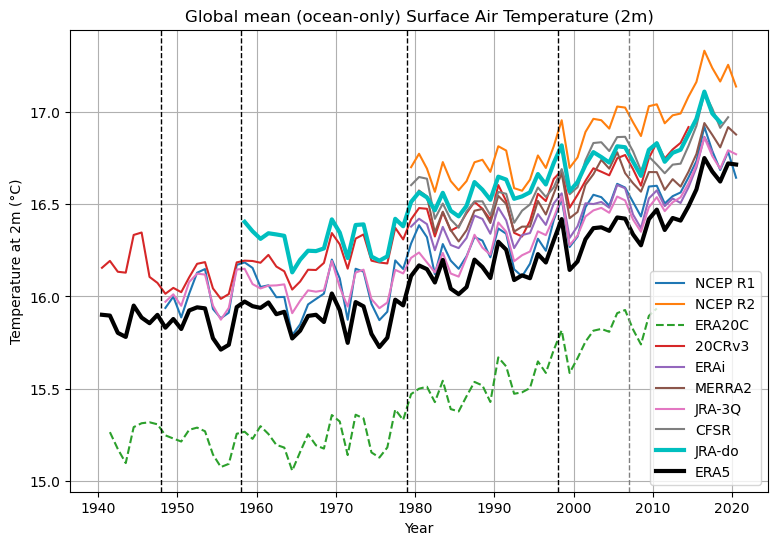

In [33]:
plt.figure(figsize=(9, 6))
n_lines = 8
# colors = cm.plasma(np.linspace(0, 1, n_lines))

# (t2_ncep_r1_mean - 273.15).plot(label = 'NCEP R1', c = 'red')
# (t2_ncep_r2_mean - 273.15).plot(label = 'NCEP R2', c = 'orangered')
# (t2_era20c_mean - 273.15).plot(label = 'ERA20C', c = 'orange', linestyle='--')
# (t2_20crv3_mean - 273.15).plot(label = '20CRv3', c = 'green')
# (t2_erai_mean - 273.15).plot(label = 'ERAi', c = 'dodgerblue')
# (t2_merra2_mean - 273.15).plot(label = 'MERRA2', c = 'blue')
# (t2_jra3q_mean - 273.15).plot(label = 'JRA-3Q', c = 'darkviolet')
# (t2_cfsr_mean - 273.15).plot(label = 'CFSR', c = 'magenta')


(t2_ncep_r1_mean - 273.15).plot(label = 'NCEP R1')
(t2_ncep_r2_mean - 273.15).plot(label = 'NCEP R2')
(t2_era20c_mean - 273.15).plot(label = 'ERA20C', linestyle='--')
(t2_20crv3_mean - 273.15).plot(label = '20CRv3')
(t2_erai_mean - 273.15).plot(label = 'ERAi')
(t2_merra2_mean - 273.15).plot(label = 'MERRA2')
(t2_jra3q_mean - 273.15).plot(label = 'JRA-3Q')
(t2_cfsr_mean - 273.15).plot(label = 'CFSR')


(t2_jrado_mean - 273.15).plot(label = 'JRA-do', c = 'c', linewidth=3)
(t2_era5_mean - 273.15).plot(label = 'ERA5', c = 'k', linewidth=3)

plt.axvline(x=pd.Timestamp('1948-01-01'), color='k', linestyle='--', linewidth=1)
plt.axvline(x=pd.Timestamp('1958-01-01'), color='k', linestyle='--', linewidth=1)
plt.axvline(x=pd.Timestamp('1979-01-01'), color='k', linestyle='--', linewidth=1)
plt.axvline(x=pd.Timestamp('1998-01-01'), color='k', linestyle='--', linewidth=1)
plt.axvline(x=pd.Timestamp('2007-01-01'), color='gray', linestyle='--', linewidth=1)
plt.xlabel('Year')
plt.ylabel('Temperature at 2m (°C)')
plt.title('Global mean (ocean-only) Surface Air Temperature (2m)')
plt.grid(True)
plt.legend()

In [34]:
# Stack your time series into a 2D array: (ensemble, time)
datasets = np.stack([
    t2_ncep_r1_mean,
    t2_ncep_r2_mean.isel(level=0),
    # t2_era20c_mean,
    t2_20crv3_mean,
    t2_cfsr_mean,
    t2_merra2_mean,
    t2_jra3q_mean,
    t2_erai_mean
])

# Convert to Celsius if needed
datasets = datasets - 273.15

# Define weights: shape (ensemble,)
# weights = np.array([0.5, 0.5, 0.5, 1.0, 1.0, 1.0, 1.0, 1.0])
weights = np.array([0.5, 0.5, 1.0, 1.0, 1.0, 1.0, 1.0])


# # Weighted average over the first axis (ensemble)
# ens_mean_weighted_np = np.sum(weights[:, None] * datasets, axis=0) / np.sum(weights)

# # Re-wrap as DataArray
# ens_mean_weighted = xr.DataArray(
#     ens_mean_weighted_np,
#     dims=["time"],
#     coords={"time": t2_era20c_interp.time},  # or whatever shared time axis you used
#     name="t2_ensemble_mean"
# )


# Step 4: Expand weights to (ensemble, time)
weights_expanded = np.broadcast_to(weights[:, None], datasets.shape)

# Step 5: Use np.nansum to ignore NaNs in numerator and denominator
numerator = np.nansum(weights_expanded * datasets, axis=0)
denominator = np.nansum(weights_expanded * ~np.isnan(datasets), axis=0)

ens_mean_weighted_np = numerator / denominator

In [35]:
ens_mean_weighted = xr.DataArray(
    ens_mean_weighted_np,
    dims=["time"],
    coords={"time": t2_era20c_mean.time},
    name="t2_ensemble_mean"
)

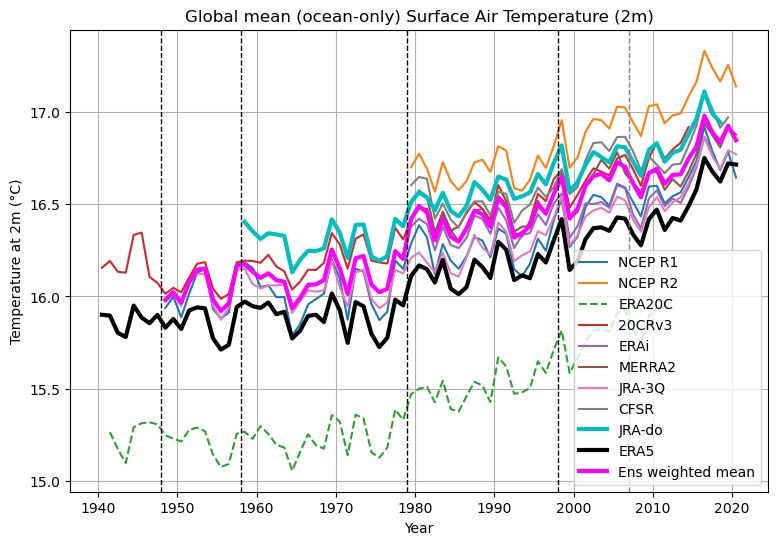

In [45]:
plt.figure(figsize=(9, 6))

(t2_ncep_r1_mean - 273.15).plot(label = 'NCEP R1')
(t2_ncep_r2_mean - 273.15).plot(label = 'NCEP R2')
(t2_era20c_mean - 273.15).plot(label = 'ERA20C', linestyle='--')
(t2_20crv3_mean - 273.15).plot(label = '20CRv3')
(t2_erai_mean - 273.15).plot(label = 'ERAi')
(t2_merra2_mean - 273.15).plot(label = 'MERRA2')
(t2_jra3q_mean - 273.15).plot(label = 'JRA-3Q')
(t2_cfsr_mean - 273.15).plot(label = 'CFSR')


(t2_jrado_mean - 273.15).plot(label = 'JRA-do', c = 'c', linewidth=3)
(t2_era5_mean - 273.15).plot(label = 'ERA5', c = 'k', linewidth=3)

ens_mean_weighted.sel(time = slice("1948", "2020")).plot(label = 'Ens weighted mean', linewidth=3, c = "magenta")

plt.axvline(x=pd.Timestamp('1948-01-01'), color='k', linestyle='--', linewidth=1)
plt.axvline(x=pd.Timestamp('1958-01-01'), color='k', linestyle='--', linewidth=1)
plt.axvline(x=pd.Timestamp('1979-01-01'), color='k', linestyle='--', linewidth=1)
plt.axvline(x=pd.Timestamp('1998-01-01'), color='k', linestyle='--', linewidth=1)
plt.axvline(x=pd.Timestamp('2007-01-01'), color='gray', linestyle='--', linewidth=1)
plt.xlabel('Year')
plt.ylabel('Temperature at 2m (°C)')
plt.title('Global mean (ocean-only) Surface Air Temperature (2m)')
plt.grid(True)
plt.legend()

In [41]:
ens_mean_weighted.time.sel(time = slice("1958", "2020")).

<xarray.DataArray 'time' (time: 63)> Size: 504B
array(['1958-07-01T05:30:00.000000000', '1959-07-01T05:30:00.000000000',
       '1960-07-01T05:30:00.000000000', '1961-07-01T05:30:00.000000000',
       '1962-07-01T05:30:00.000000000', '1963-07-01T05:30:00.000000000',
       '1964-07-01T05:30:00.000000000', '1965-07-01T05:30:00.000000000',
       '1966-07-01T05:30:00.000000000', '1967-07-01T05:30:00.000000000',
       '1968-07-01T05:30:00.000000000', '1969-07-01T05:30:00.000000000',
       '1970-07-01T05:30:00.000000000', '1971-07-01T05:30:00.000000000',
       '1972-07-01T05:30:00.000000000', '1973-07-01T05:30:00.000000000',
       '1974-07-01T05:30:00.000000000', '1975-07-01T05:30:00.000000000',
       '1976-07-01T05:30:00.000000000', '1977-07-01T05:30:00.000000000',
       '1978-07-01T05:30:00.000000000', '1979-07-01T05:30:00.000000000',
       '1980-07-01T05:30:00.000000000', '1981-07-01T05:30:00.000000000',
       '1982-07-01T05:30:00.000000000', '1983-07-01T05:30:00.000000000',
       '1984-07-01T05:30:00.000000000', '1985-07-01T05:30:00.000000000',
       '1986-07-01T05:30:00.000000000', '1987-07-01T05:30:00.000000000',
       '1988-07-01T05:30:00.000000000', '1989-07-01T05:30:00.000000000',
       '1990-07-01T05:30:00.000000000', '1991-07-01T05:30:00.000000000',
       '1992-07-01T05:30:00.000000000', '1993-07-01T05:30:00.000000000',
       '1994-07-01T05:30:00.000000000', '1995-07-01T05:30:00.000000000',
       '1996-07-01T05:30:00.000000000', '1997-07-01T05:30:00.000000000',
       '1998-07-01T05:30:00.000000000', '1999-07-01T05:30:00.000000000',
       '2000-07-01T05:30:00.000000000', '2001-07-01T05:30:00.000000000',
       '2002-07-01T05:30:00.000000000', '2003-07-01T05:30:00.000000000',
       '2004-07-01T05:30:00.000000000', '2005-07-01T05:30:00.000000000',
       '2006-07-01T05:30:00.000000000', '2007-07-01T05:30:00.000000000',
       '2008-07-01T05:30:00.000000000', '2009-07-01T05:30:00.000000000',
       '2010-07-01T05:30:00.000000000', '2011-07-01T05:30:00.000000000',
       '2012-07-01T05:30:00.000000000', '2013-07-01T05:30:00.000000000',
       '2014-07-01T05:30:00.000000000', '2015-07-01T05:30:00.000000000',
       '2016-07-01T05:30:00.000000000', '2017-07-01T05:30:00.000000000',
       '2018-07-01T05:30:00.000000000', '2019-07-01T05:30:00.000000000',
       '2020-07-01T05:30:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 504B 1958-07-01T05:30:00 ... 2020-07-01T05...

In [37]:
years = pd.to_datetime(t2_20crv3_mean['time'].values).year

for i, name in enumerate([
    'NCEP R1',
    'NCEP R2',
    '20CRv3',
    'CFSR',
    'MERRA2',
    'JRA-3Q',
    'ERAi'
]):
    first_valid_index = np.where(~np.isnan(datasets[i]))[0][0]
    print(f"{name} starts in year: {years[first_valid_index]}")

NCEP R1 starts in year: 1948
NCEP R2 starts in year: 1979
20CRv3 starts in year: 1940
CFSR starts in year: 1979
MERRA2 starts in year: 1980
JRA-3Q starts in year: 1948
ERAi starts in year: 1979
